# 07 · Phase tracking: the frame phases between the two subspaces (2022–2024)

A qutrit driven as two coupled two-level systems has two rotating frames, one at $\omega_{01}$ and one at $\omega_{12}$. A pulse on
one transition is not invisible to the other: after an X12 pulse the 0–1 Ramsey phase has moved by β; after an X01 pulse the
1–2 frame has moved by α. These "frame phases" (the paper calls their accumulation *phase advance*) must be tracked and compensated
with virtual Z's, otherwise a sequence that alternates subspaces (every Clifford!) is wrong after a few gates.

Three protocols were used to measure them:

1. **Ramsey-like** (Aug–Sep 2022, `ibm_oslo` / `ibmq_manila`; Aug 2023 `ibm_lagos`): a 0–1 Ramsey whose idle time is filled with
   $8n$ X12($\pi/2$) pulses; the fringe shifts by $8n\beta$.
2. **Randomised phase circuits, RPC** (Aug 2022 `find_phase`; Aug 2023 `ibm_lagos`; Jan–Feb 2024 `ibm_brisbane`): random strings of
   R01/R12 rotations with random angles; the three phases (α, β, γ) are fitted by least squares on the measured populations.
3. **Pseudo-identity Ramsey, "Ramsey v1"** (Apr 2024, `ibm_brisbane` q109): the idle time is filled with $n$ pseudo-identities
   (SX12 SX12⁻¹); each one leaves 2β behind. This is the protocol of the 2025 paper (notebook 08).

The models are in `pulseshop.phase_tracking`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt
from pulseshop import phase_tracking as pt, qutrit as Q, fitting, io
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
pi = np.pi

## 1. The Ramsey-like protocol of 2022

Y01($\pi/2$) · [X12($\pi/2$)]$^{8n}$ · Y01($-\pi/2 + 8n\varphi$): if every X12($\pi/2$) kicks the 0–1 frame by β, the ground-state population
after the last pulse depends on $n$ and on the correction φ as `model_zero_population(beta, n)`. Sweeping the correction over a narrow window
and $n$ over 1…30 gives a heat map whose bright stripe tracks β (figures `lab_2022/oslo_q0_2022-08_ramsey_like_heatmap_*`).

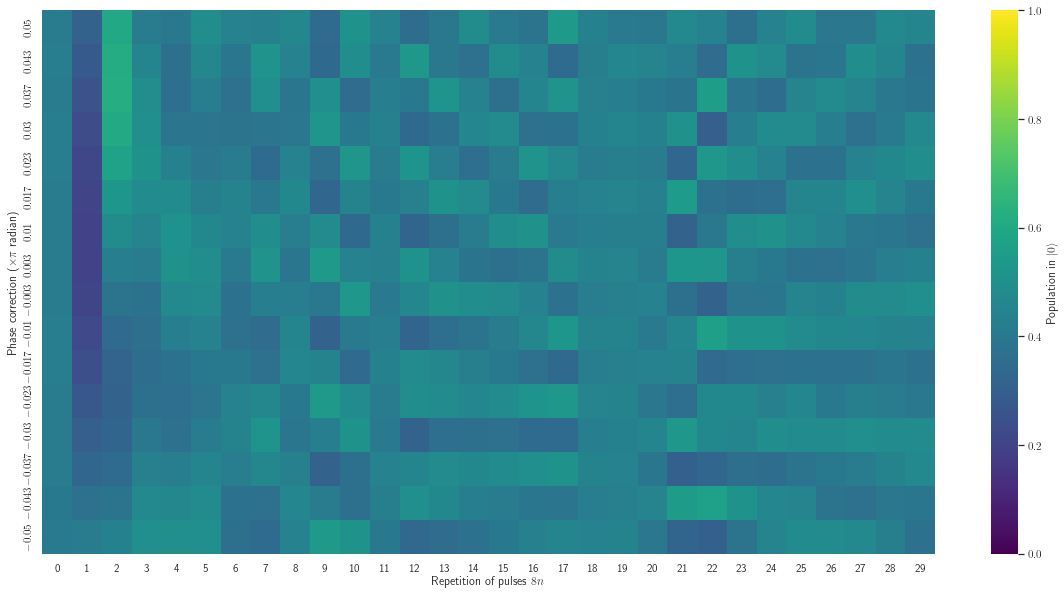

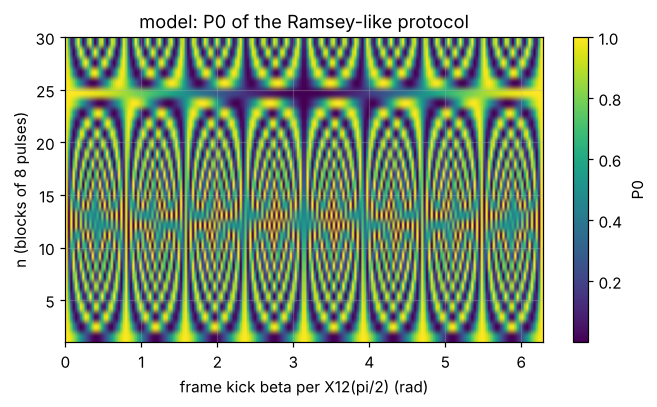

In [2]:
from IPython.display import Image, display
display(Image(filename=str(io.FIG_DIR / "lab_2022/oslo_q0_2022-08_ramsey_like_heatmap_pm_pi_over_20.png"), width=700))

alphas = np.linspace(0, 2 * pi, 200)
ns = np.arange(1, 31)
grid = np.array([[pt.model_zero_population(a, n) for n in ns] for a in alphas])
fig, ax = plt.subplots(figsize=(7, 3.6))
im = ax.imshow(grid.T, origin="lower", aspect="auto", extent=[0, 2 * pi, 1, 30], cmap="viridis")
ax.set(xlabel="frame kick beta per X12(pi/2) (rad)", ylabel="n (blocks of 8 pulses)", title="model: P0 of the Ramsey-like protocol")
plt.colorbar(im, ax=ax, label="P0")
io.save_fig(fig, "07_ramsey_like_model_map")

The manila run of Sep 2022 (`Ramseyy_ver2`) measured the first four sequences with 8 gates each (populations in `manila_2022-09-20_ramsey_8gates_populations.csv`):

In [3]:
p8 = io.load_csv("lab_2022", "manila_2022-09-20_ramsey_8gates_populations.csv")
print("rows: |0>, |1>, |2> calibration circuits and the Ramsey sequence with 8 X12(pi/2) pulses")
print(np.round(p8, 3))

rows: |0>, |1>, |2> calibration circuits and the Ramsey sequence with 8 X12(pi/2) pulses
[[0.965 0.012 0.023]
 [0.034 0.834 0.132]
 [0.013 0.149 0.838]
 [0.457 0.255 0.288]]


## 2. Randomised phase circuits

With no data files left from the `ibm_lagos` (2023) and `ibm_brisbane` (Jan–Feb 2024) RPC runs — only the fitted numbers in the
notebooks — the protocol is demonstrated on synthetic data: 97 random circuits of a given `order` ('1' = R01, '2' = R12), random
(θ, φ) per gate, populations from the model with "true" phases plus shot noise, and the least-squares fit of `fit_phases` recovering them.

order: 1221121


true  (alpha, beta, gamma) mod 2pi: [0.61 0.73 6.24]
fitted                          : [0.615 0.728 6.24 ]  loss 0.0091  r2 per level [0.999 0.998 0.998]


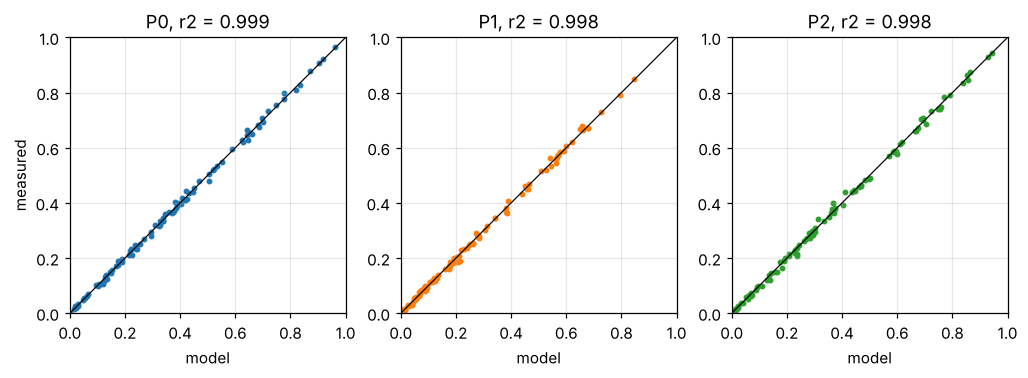

In [4]:
rng = np.random.default_rng(7)
order = "1221121"          # which subspace each of the 7 rotations acts on (pt.create_order draws one at random)
thetas = rng.uniform(0, pi, (97, len(order))); phis = rng.uniform(0, pi, (97, len(order)))
true = (0.61, 0.73, 6.24 - 2 * pi)     # alpha, beta, gamma of the lagos fits (gamma wrapped)
p_true = np.array([pt.population_model_rpc(thetas[i], phis[i], *true, order) for i in range(97)])
p_meas = np.array([rng.multinomial(2000, p) / 2000 for p in p_true])
print("order:", order)

def model(params_i, a, b, g, order):
    th, ph = params_i
    return pt.population_model_rpc(th, ph, a, b, g, order)

x_opt, loss, r2, p_model = pt.fit_phases(model, list(zip(thetas, phis)), p_meas, order, n_params=3, n_seeds=8, rng=rng)
print("true  (alpha, beta, gamma) mod 2pi:", np.round(np.mod(true, 2 * pi), 3))
print("fitted                          :", np.round(x_opt, 3), " loss", round(loss, 4), " r2 per level", np.round(r2, 3))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for k, ax in enumerate(axes):
    ax.scatter(p_model[:, k], p_meas[:, k], s=8, color=f"C{k}")
    ax.plot([0, 1], [0, 1], "k-", lw=0.8)
    ax.set(xlabel="model", ylabel="measured" if k == 0 else "", title=f"P{k}, r2 = {r2[k]:.3f}", xlim=(0, 1), ylim=(0, 1), aspect="equal")
io.save_fig(fig, "07_rpc_synthetic_fit")

This is exactly the plot the 2023–24 notebooks produced for each job (model vs measured for the three levels, with $r^2$ in the titles).
On hardware the fits of Aug 2023 (`ibm_lagos`) clustered at α ≈ 0, β ≈ −π/4, γ ≈ +π/4 for the Gaussian pulses of the day
and α, β, γ = (0.610, 0.730, 6.243) for the DRAG pulses used in RB; the Feb 2024 `ibm_brisbane` run (`report_phase2`) gave
$(\phi^{(01)}_2, \phi^{(12)}_0) = (2.664, 1.058)$ for the two-parameter model.

## 3. Ramsey v1 on `ibm_brisbane` q109 (April 2024)

`experiment/ramseyv1/ramseyv1.ipynb` measured β with SX01 → $n$ × (SX12 SX12⁻¹) → SX01(φ), and α with X01, SX12 → $n$ × (SX01 SX01⁻¹) → SX12(φ),
$n = 0 … 9$, φ swept over 100 values from $-\pi/6$ to $-\pi/6 + 2\pi$, 2048 shots, LDA readout + mitigation. Each pseudo-identity should leave
2β (resp. 2α) behind, so the fringe phase is linear in $n$.

round3_23april24   beta: fringe shift per pseudo-identity = -2.118 rad  ->  |beta| = |shift|/2 = 1.059 rad = 0.337 pi (mod pi)
round3_23april24   alpha: fringe shift per pseudo-identity = +0.909 rad  ->  |alpha| = |shift|/2 = 0.455 rad = 0.145 pi (mod pi)
round2_18april24   beta: fringe shift per pseudo-identity = +1.646 rad  ->  |beta| = |shift|/2 = 0.823 rad = 0.262 pi (mod pi)
round2_18april24   alpha: fringe shift per pseudo-identity = +0.412 rad  ->  |alpha| = |shift|/2 = 0.206 rad = 0.066 pi (mod pi)
notebook of the day (fits by eye): beta = pi - 2pi/3 = 1.047  alpha = pi - pi/7 = 2.693 = -0.449 mod pi


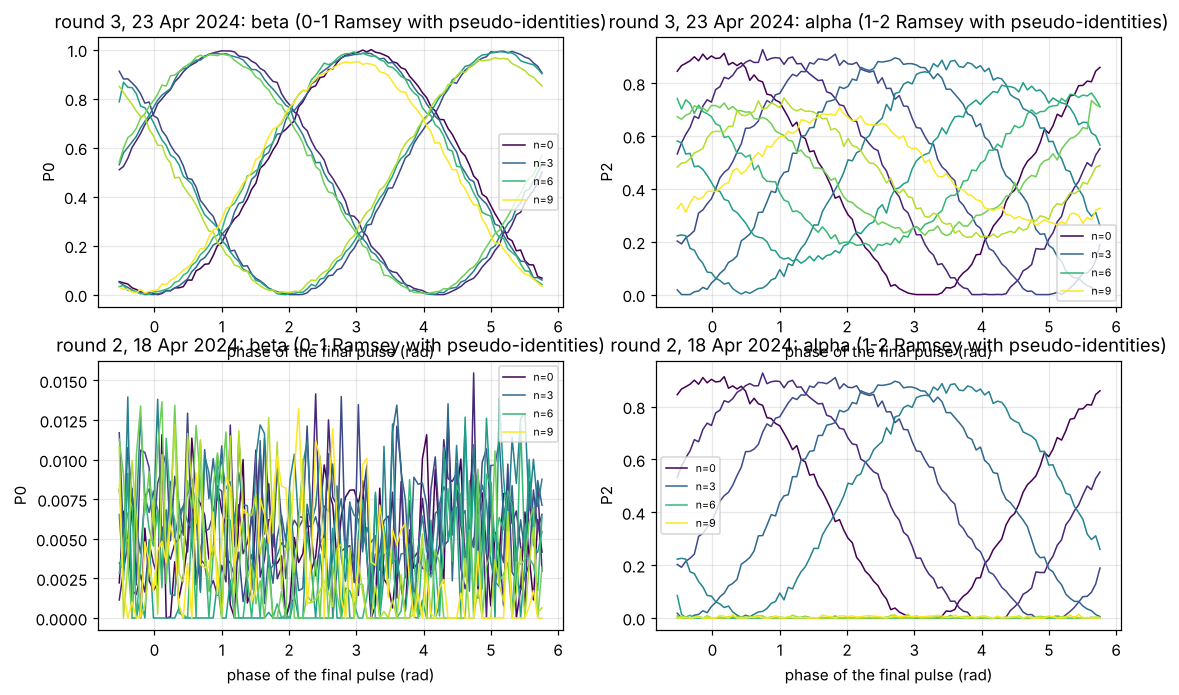

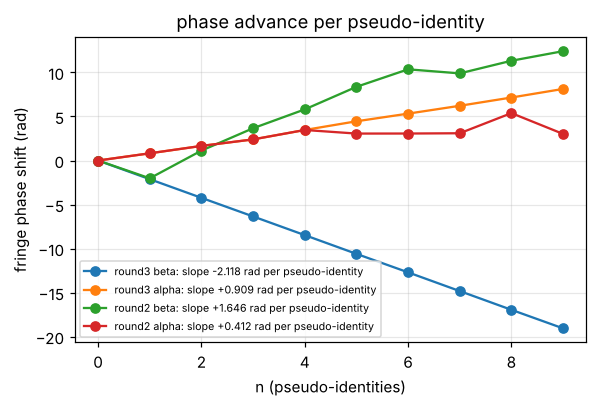

In [5]:
phases = np.linspace(-pi / 6, -pi / 6 + 2 * pi, 100)

def load_ramseyv1(round_dir, kind):
    pops = []
    for f, reps in [("01234", range(0, 5)), ("56789", range(5, 10))]:
        try:
            a = io.load_npy(f"shop_2024/experiment/ramseyv1/data/{round_dir}/{kind}/mitigated", f"{f}.npy").reshape(5, 100, 3)
            pops.append(a)
        except FileNotFoundError:
            pass
    return np.concatenate(pops) if pops else None

def fringe_phases(pops, level):
    out = []
    for n in range(pops.shape[0]):
        y = pops[n, :, level]
        pars, yfit = fitting.fit_function(phases, y, fitting.cosine, [(y.max() - y.min()) / 2, y.mean(), 2 * pi, phases[np.argmax(y)]])[:2]
        if pars[0] < 0:
            pars[0] *= -1; pars[3] += pi
        out.append(pars[3])
    return np.unwrap(np.array(out))

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
summary = {}
for row, (rd, lab) in enumerate([("round3_23april24", "round 3, 23 Apr 2024"), ("round2_18april24", "round 2, 18 Apr 2024")]):
    for col, (kind, level) in enumerate([("beta", 0), ("alpha", 2)]):
        pops = load_ramseyv1(rd, kind)
        if pops is None:
            continue
        ax = axes[row, col]
        for n in range(pops.shape[0]):
            ax.plot(phases, pops[n, :, level], "-", color=plt.cm.viridis(n / 9), lw=1, label=f"n={n}" if n % 3 == 0 else None)
        ax.set(xlabel="phase of the final pulse (rad)", ylabel=f"P{level}", title=f"{lab}: {kind} ({'0-1' if kind=='beta' else '1-2'} Ramsey with pseudo-identities)")
        ax.legend(fontsize=7)
        ph = fringe_phases(pops, level)
        n = np.arange(len(ph))
        m, c = np.polyfit(n, ph, 1)
        summary[(rd, kind)] = (n, ph, m)
io.save_fig(fig, "07_ramseyv1_fringes_apr2024")

fig, ax = plt.subplots(figsize=(6, 3.6))
for (rd, kind), (n, ph, m) in summary.items():
    ax.plot(n, ph - ph[0], "o-", label=f"{rd[:6]} {kind}: slope {m:+.3f} rad per pseudo-identity")
ax.set(xlabel="n (pseudo-identities)", ylabel="fringe phase shift (rad)", title="phase advance per pseudo-identity"); ax.legend(fontsize=7)
io.save_fig(fig, "07_ramseyv1_phase_vs_n")
for (rd, kind), (n, ph, m) in summary.items():
    print(f"{rd:18s} {kind}: fringe shift per pseudo-identity = {m:+.3f} rad  ->  |{kind}| = |shift|/2 = {abs(m)/2:.3f} rad = {abs(m)/2/pi:.3f} pi (mod pi)")
print("notebook of the day (fits by eye): beta = pi - 2pi/3 =", round(pi - 2*pi/3, 3), " alpha = pi - pi/7 =", round(pi - pi/7, 3), "=", round(pi - pi/7 - pi, 3), "mod pi")

Round 3 reproduces the values the notebook of the day found by eye: |β| = 1.06 (π − 2π/3 = 1.047) and |α| = 0.455 (π − π/7 ≡ −0.449 mod π).
Only 2β is measured, so β is defined modulo π and up to the sign convention of the phase sweep. Round 2 (18 Apr) was taken with
different pulse amplitudes and gives different kicks — the frame phases are properties of the *pulses*, not of the qubit, which is why
they have to be re-measured after every recalibration. The paper (notebook 08) finds β ≈ π − 0.93 and α ≈ π − π/7 − 0.015 for the 20 ns pulses.

Overlaying the model (`phase_advance_sim`, the same function as in notebook 08) on the round-3 β data:

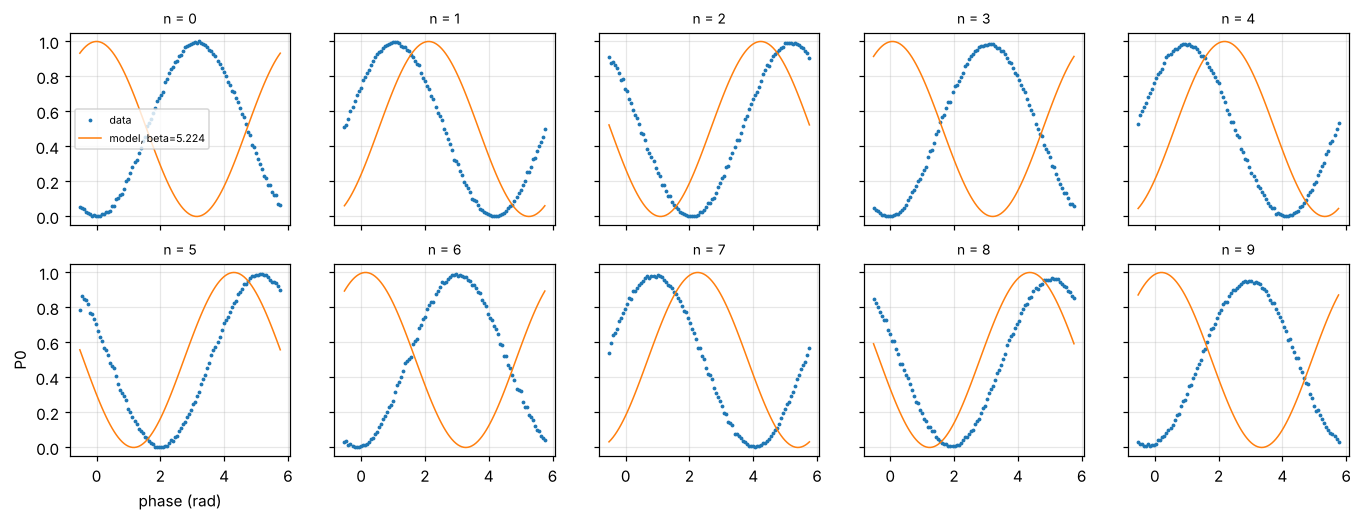

In [6]:
pops = load_ramseyv1("round3_23april24", "beta")
m = summary[("round3_23april24", "beta")][2]
cands = [(m / 2) % (2 * pi), (-m / 2) % (2 * pi)]
sims = [pt.phase_advance_sim("beta", phases, list(range(10)), beta=b) for b in cands]
k = int(np.argmin([np.mean((sm[:, :, 0] - pops[:, :, 0]) ** 2) for sm in sims]))
beta_fit, sim = cands[k], sims[k]
fig, axes = plt.subplots(2, 5, figsize=(15, 5), sharex=True, sharey=True)
for n, ax in enumerate(axes.ravel()):
    ax.plot(phases, pops[n, :, 0], ".", ms=3, label="data")
    ax.plot(phases, sim[n, :, 0], "-", lw=1, label=f"model, beta={beta_fit:.3f}")
    ax.set_title(f"n = {n}", fontsize=9)
axes[0, 0].legend(fontsize=7); axes[1, 0].set(xlabel="phase (rad)", ylabel="P0")
io.save_fig(fig, "07_ramseyv1_beta_model_overlay")

The model captures the fringe positions; the loss of contrast with $n$ (visible from $n \approx 6$) is decoherence during the
pseudo-identities, which the unitary model does not have. Notebook 08 repeats this experiment with the 20 ns pulses and 5 000 shots.